<a href="https://colab.research.google.com/github/Chaidir110/PCVK_Ganjil_2025/blob/main/week6_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D. PRAKTIKUM FILTER

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [20]:
# --- Fungsi Konvolusi 2D (grayscale) ---
def convolution2d(image, kernel, stride, padding):
    # 1. Menyiapkan variabel dimensi
    h_img, w_img = image.shape
    h_ker, w_ker = kernel.shape

    # 2. Menghitung dimensi output
    h_out = int(((h_img - h_ker + 2 * padding) / stride) + 1)
    w_out = int(((w_img - w_ker + 2 * padding) / stride) + 1)

    # 3. Menambahkan padding
    if padding > 0:
        padded_image = np.zeros((h_img + 2 * padding, w_img + 2 * padding))
        padded_image[padding:-padding, padding:-padding] = image
    else:
        padded_image = image

    # 4. Membuat matriks output
    output = np.zeros((h_out, w_out))

    # 5. Proses konvolusi
    for y in range(h_out):
        for x in range(w_out):
            y_start, y_end = y * stride, y * stride + h_ker
            x_start, x_end = x * stride, x * stride + w_ker
            image_slice = padded_image[y_start:y_end, x_start:x_end]
            output[y, x] = np.sum(image_slice * kernel)

    return output

Sharpen

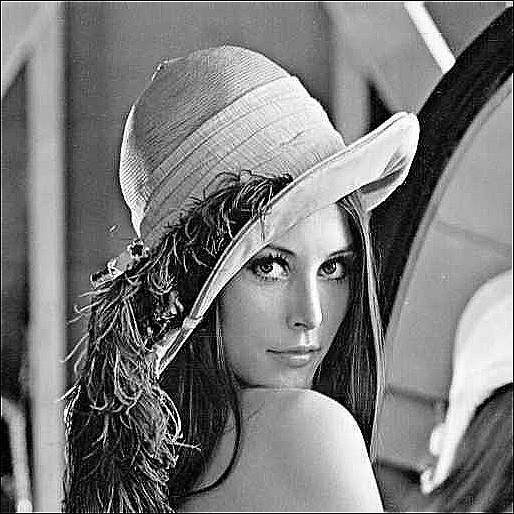

In [22]:
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#image sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# memanggil fungsi konvolusi
output = convolution2d(img_gray, kernel_sharpen, stride=1, padding=2)

# menampilkan hasil
cv2_imshow(output)

Emboss

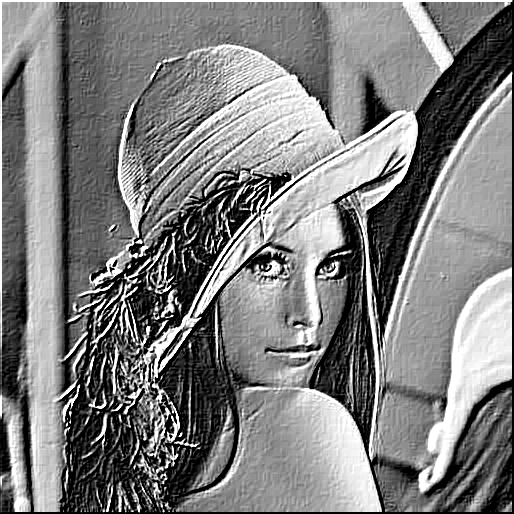

In [10]:
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#image sharpen
kernel_emboss = np.array([[-2, -1, 0],
                           [-1, 1, 1],
                           [0, 1, 2]])

# memanggil fungsi konvolusi
output = convolution2d(img_gray, kernel_emboss, stride=1, padding=2)

# menampilkan hasil
cv2_imshow(output)

Left Sobel Edge Detection

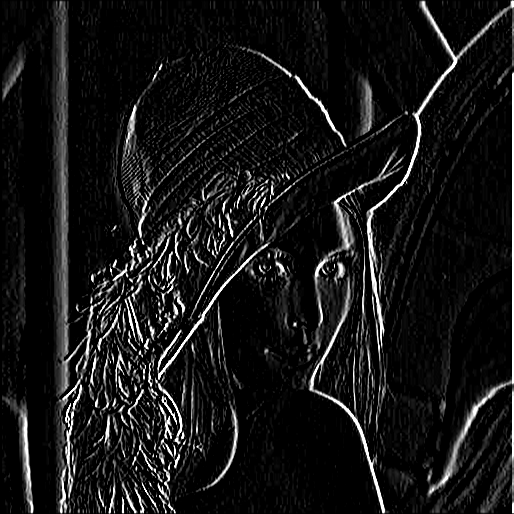

In [12]:
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#image sharpen
kernel_lsed = np.array([[1, 0, -1],
                        [2, 0, -2],
                        [1, 0, -1]])

# memanggil fungsi konvolusi
output = convolution2d(img_gray, kernel_lsed, stride=1, padding=2)

# menampilkan hasil
cv2_imshow(output)

Canny Edge Detection

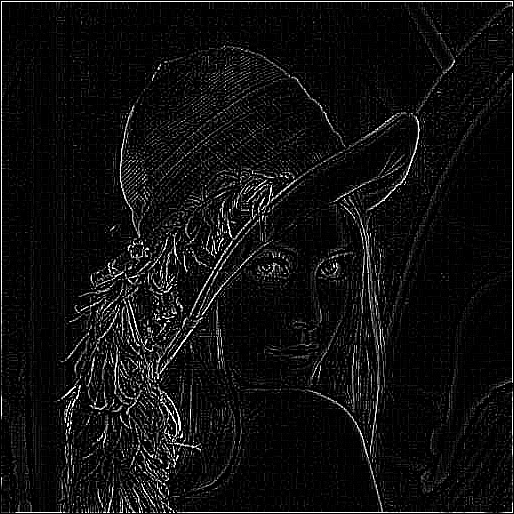

In [13]:
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#image sharpen
kernel_canny = np.array([[-1, -1, -1],
                        [-1, 8, -1],
                        [-1, -1, -1]])

# memanggil fungsi konvolusi
output = convolution2d(img_gray, kernel_canny, stride=1, padding=2)

# menampilkan hasil
cv2_imshow(output)

21x21 Gaussian Blur

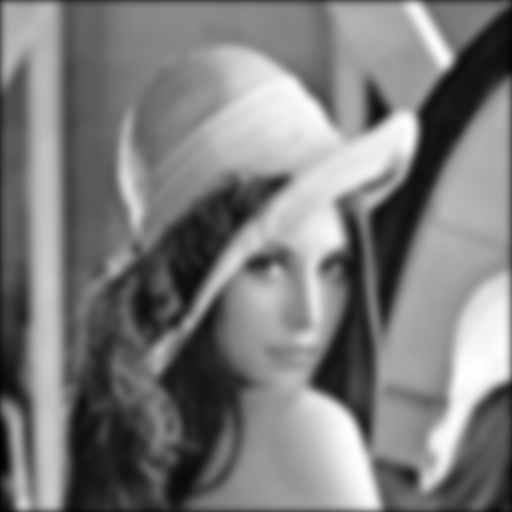

In [23]:
# --- Membuat kernel Gaussian ---
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.T  # Gaussian 2D

# --- Melakukan konvolusi manual ---
output = convolution2d(img_gray, gauss_kernel, stride=1, padding=kernel_size//2)

# --- Normalisasi agar bisa ditampilkan ---
output = cv.normalize(output, None, 0, 255, cv.NORM_MINMAX)
output = output.astype(np.uint8)

# --- Tampilkan hasil ---
cv2_imshow(output)
cv.waitKey(0)
cv.destroyAllWindows()

# E. FILTER LIBRARY DAN FILTER MODERN